# Exploratory Data Analysis on Canteen Food Waste Dataset

This notebook performs an exploratory data analysis on a food waste dataset from a canteen. The data covers records from January 2015 to December 2024, with details on waste weight, cost, meal types, canteen sections, food categories, and a synthetic foot traffic measure. The goal is to understand the patterns in food waste, find which factors drive waste, and identify opportunities to reduce waste and save costs. All plots and summaries are explained in simple terms.

## 1. Setup and Data Loading

We first import the needed libraries and load the dataset.

In [33]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
GREEN_MAIN = "#2e7d32"
%matplotlib inline

In [34]:
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    os.chdir("/content/drive/MyDrive/UAB/FDS/campus-waste-intelligence")
    print("Directory changed")
except ImportError:
    print("Running locally, adjust path if needed")

Mounted at /content/drive
Directory changed


In [35]:
# Load the dataset
df = pd.read_csv('data/food_waste_augmented_cl.csv', parse_dates=['Date'])
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (76290, 27)


,Date,Meal,Canteen_Section,Food_Category,Waste_Weight_kg,Unit_Price_per_kg,Is_Event_Day,Year,Month,Day,...,Month_Name,Weekday_Type,Cost_Loss,Waste_per_Price,Log_Waste,Foot_Traffic,Is_Waste_Outlier,Is_Cost_Outlier,Is_High_Waste,Is_High_Cost
0,2015-01-01 07:30:00,Breakfast,B,Soup,2.17,1.5,0,2015,1,1,...,January,Weekday,3.25,1.443506,0.772540,96.0,0,0,0,0
1,2015-01-01 06:00:00,Breakfast,C,Meat,2.31,8.0,0,2015,1,1,...,January,Weekday,18.52,0.289299,0.839145,64.0,0,0,0,0
2,2015-01-01 07:00:00,Breakfast,B,Meat,5.00,8.0,0,2015,1,1,...,January,Weekday,40.00,0.625000,1.609438,96.0,0,1,1,1
3,2015-01-01 06:30:00,Breakfast,D,Meat,3.06,8.0,0,2015,1,1,...,January,Weekday,24.46,0.382166,1.117542,120.0,0,1,0,1
4,2015-01-01 08:00:00,Breakfast,D,Rice,5.00,2.0,0,2015,1,1,...,January,Weekday,10.00,2.500000,1.609438,120.0,0,0,1,0


In [36]:
# Basic info
df.info()
print("\nMissing values per column:\n", df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76290 entries, 0 to 76289
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Date               76290 non-null  datetime64[ns]
 1   Meal               76290 non-null  object        
 2   Canteen_Section    76290 non-null  object        
 3   Food_Category      76290 non-null  object        
 4   Waste_Weight_kg    76290 non-null  float64       
 5   Unit_Price_per_kg  76290 non-null  float64       
 6   Is_Event_Day       76290 non-null  int64         
 7   Year               76290 non-null  int64         
 8   Month              76290 non-null  int64         
 9   Day                76290 non-null  int64         
 10  Hour               76290 non-null  int64         
 11  Minute             76290 non-null  int64         
 12  Weekday            76290 non-null  object        
 13  Week               76290 non-null  int64         
 14  DayOfY

In [37]:
# Summary statistics for numerical columns
df.describe()

,Date,Waste_Weight_kg,Unit_Price_per_kg,Is_Event_Day,Year,Month,Day,Hour,Minute,Week,...,Quarter,IsWeekend,Cost_Loss,Waste_per_Price,Log_Waste,Foot_Traffic,Is_Waste_Outlier,Is_Cost_Outlier,Is_High_Waste,Is_High_Cost
count,76290,76290.000000,76290.000000,76290.000000,76290.000000,76290.000000,76290.000000,76290.000000,76290.000000,76290.000000,...,76290.000000,76290.000000,76290.000000,76290.000000,76290.000000,76290.000000,76290.0,76290.000000,76290.000000,76290.000000
mean,2020-04-21 18:15:53.818324736,2.424110,3.633858,0.029349,2019.815926,6.392044,15.688033,12.332075,14.989383,26.049692,...,2.467230,0.276655,8.642692,0.993332,0.660211,105.599205,0.0,0.082698,0.164320,0.075213
min,2015-01-01 06:00:00,0.040000,1.500000,0.000000,2015.000000,1.000000,1.000000,6.000000,0.000000,1.000000,...,1.000000,0.000000,0.140000,0.005307,-3.159242,44.800000,0.0,0.000000,0.000000,0.000000
25%,2017-08-26 07:07:30,1.190000,2.000000,0.000000,2017.000000,3.000000,8.000000,8.000000,0.000000,13.000000,...,1.000000,0.000000,2.960000,0.348056,0.169844,80.000000,0.0,0.000000,0.000000,0.000000
50%,2020-04-21 18:00:00,2.050000,3.000000,0.000000,2020.000000,6.000000,16.000000,12.000000,0.000000,26.000000,...,2.000000,0.000000,5.700000,0.695588,0.717088,100.000000,0.0,0.000000,0.000000,0.000000
75%,2022-12-16 11:00:00,3.540000,8.000000,0.000000,2022.000000,9.000000,23.000000,17.000000,30.000000,39.000000,...,3.000000,1.000000,10.000000,1.452636,1.263550,120.000000,0.0,0.000000,0.000000,0.000000
max,2025-08-10 19:30:00,5.000000,8.000000,1.000000,2025.000000,12.000000,31.000000,19.000000,30.000000,53.000000,...,4.000000,1.000000,40.000000,3.333333,1.609438,324.000000,0.0,1.000000,1.000000,1.000000
std,NaN,1.489118,2.580239,0.168783,3.068232,3.431469,8.804377,4.577023,15.000095,14.977924,...,1.111893,0.447347,8.895717,0.838919,0.720283,36.912674,0.0,0.275426,0.370568,0.263736


## 2. Feature Engineering

We add date‑based features to help with time analysis.

In [38]:
# Extract time components
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Weekday'] = df['Date'].dt.day_name()
df['Week'] = df['Date'].dt.isocalendar().week
df['Hour'] = df['Date'].dt.hour
df['Minute'] = df['Date'].dt.minute
df['IsWeekend'] = df['Weekday'].isin(['Saturday','Sunday']).astype(int)
df['Weekday_num'] = df['Date'].dt.dayofweek

## 3. Helper Functions

We define a few functions to make plotting simpler and consistent.

In [39]:
def plot_histogram(data, column, bins=50, kde=True, title=None):
    """Plot a histogram for a numeric column."""
    plt.figure(figsize=(10, 4))
    sns.histplot(data[column], bins=bins, kde=kde, color=GREEN_MAIN)
    plt.title(title or f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Density')
    plt.show()

def plot_count(data, column, title=None, rotation=45):
    """Plot a bar chart of counts for a categorical column."""
    plt.figure(figsize=(8, 5))
    sns.countplot(data=data, x=column, order=data[column].value_counts().index, color=GREEN_MAIN)
    plt.title(title or f'Count of {column}')
    plt.xticks(rotation=rotation)
    plt.show()

def plot_box(data, x, y, title=None):
    """Create a boxplot for a categorical vs numeric."""
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=data, x=x, y=y, color=GREEN_MAIN)
    plt.title(title or f'{y} by {x}')
    plt.xticks(rotation=45)
    plt.show()

def plot_line(data, x, y, title=None):
    """Plot a line chart."""
    plt.figure(figsize=(10, 5))
    sns.lineplot(data=data, x=x, y=y, marker='o', color=GREEN_MAIN)
    plt.title(title or f'{y} vs {x}')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

def barplot_with_percentage(data, x_col, y_col, title, rotate=False, width=0.4):
    """Bar chart with percentage labels on top."""
    df_plot = data.copy()
    total = df_plot[y_col].sum()
    df_plot['Percentage'] = (df_plot[y_col] / total) * 100
    df_plot = df_plot.sort_values(by=y_col, ascending=False).reset_index(drop=True)
    plt.figure(figsize=(10, 6))
    palette = sns.color_palette("Greens", len(df_plot))
    ax = sns.barplot(data=df_plot, x=x_col, y=y_col, hue=x_col, palette=palette, legend=False, width=width)
    max_val = df_plot[y_col].max()
    for i, row in df_plot.iterrows():
        ax.text(i, row[y_col] + (max_val * 0.02), f"{row['Percentage']:.1f}%", ha='center')
    plt.title(title)
    plt.ylim(0, max_val * 1.15)
    if rotate:
        plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def plot_time_series(data, date_col, value_col, resample_freq='D', title=None):
    """Plot aggregated time series."""
    ts = data.set_index(date_col)[value_col].resample(resample_freq).sum()
    plt.figure(figsize=(14, 5))
    ts.plot(color=GREEN_MAIN)
    plt.title(title or f'{value_col} ({resample_freq} aggregation)')
    plt.ylabel(value_col)
    plt.xlabel('Date')
    plt.grid(True)
    plt.show()
    return ts

## 4. Univariate Analysis

We start by looking at the distribution of the main numerical and categorical variables.

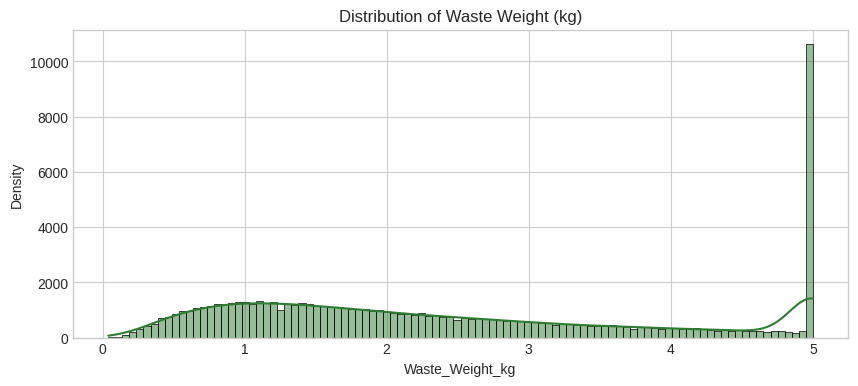

Waste weight skewness: 0.52
Waste weight kurtosis: -1.01


In [40]:
# Distribution of waste weight
plot_histogram(df, 'Waste_Weight_kg', bins=100, title='Distribution of Waste Weight (kg)')
print(f"Waste weight skewness: {df['Waste_Weight_kg'].skew():.2f}")
print(f"Waste weight kurtosis: {df['Waste_Weight_kg'].kurtosis():.2f}")

The waste weight is heavily right‑skewed: most waste events are small, but there are occasional very large ones. This pattern is common in food waste data and means any prediction model should be able to handle these extremes.

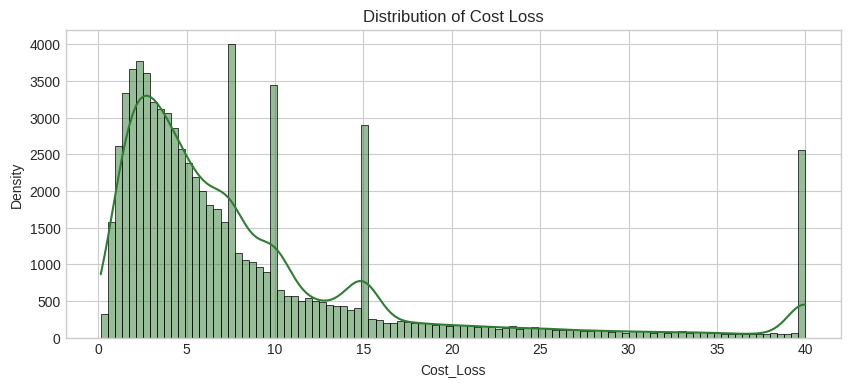

Cost loss skewness: 2.12


In [41]:
# Cost loss distribution
plot_histogram(df, 'Cost_Loss', bins=100, title='Distribution of Cost Loss')
print(f"Cost loss skewness: {df['Cost_Loss'].skew():.2f}")

Cost loss follows the same skewed pattern, driven by waste weight and unit price. Most events cost little, but a few are very expensive.

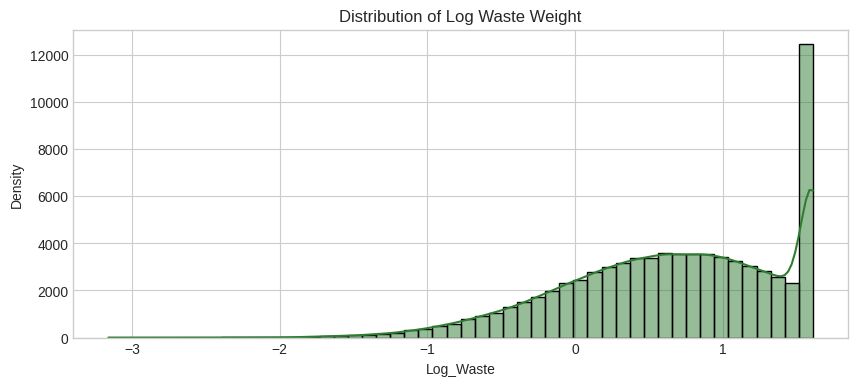

Log waste skewness: -0.52


In [42]:
# Log waste distribution
plot_histogram(df, 'Log_Waste', bins=50, title='Distribution of Log Waste Weight')
print(f"Log waste skewness: {df['Log_Waste'].skew():.2f}")

After taking the log, the distribution becomes nearly symmetric, which confirms the waste weights follow a log‑normal pattern. This is useful for modeling.

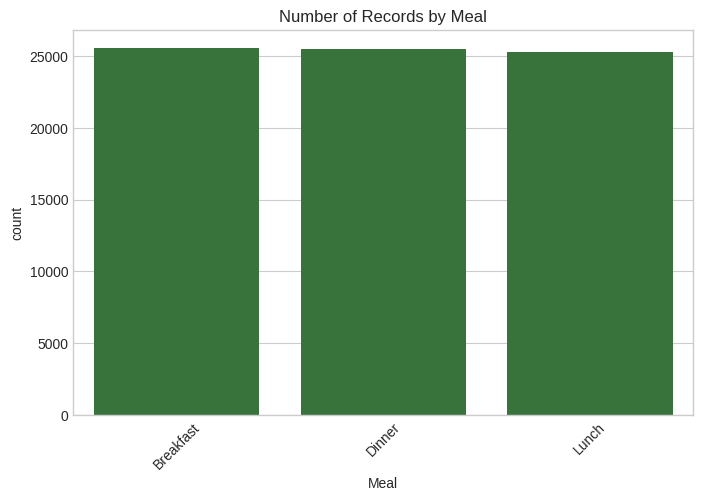

In [43]:
# Count of records by Meal
plot_count(df, 'Meal', title='Number of Records by Meal')

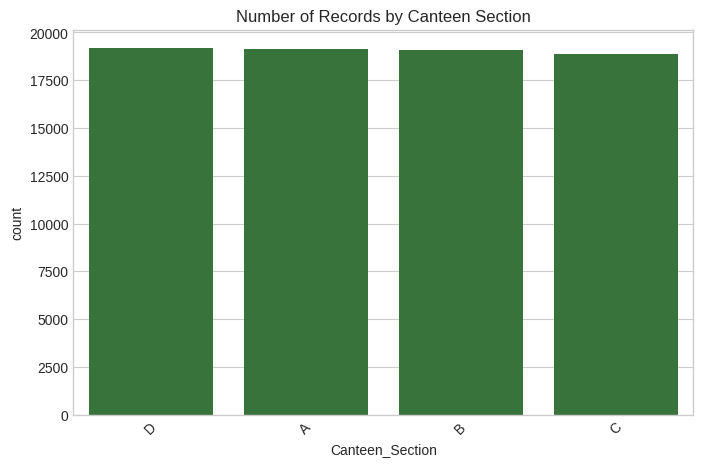

In [44]:
# Count of records by Canteen Section
plot_count(df, 'Canteen_Section', title='Number of Records by Canteen Section')

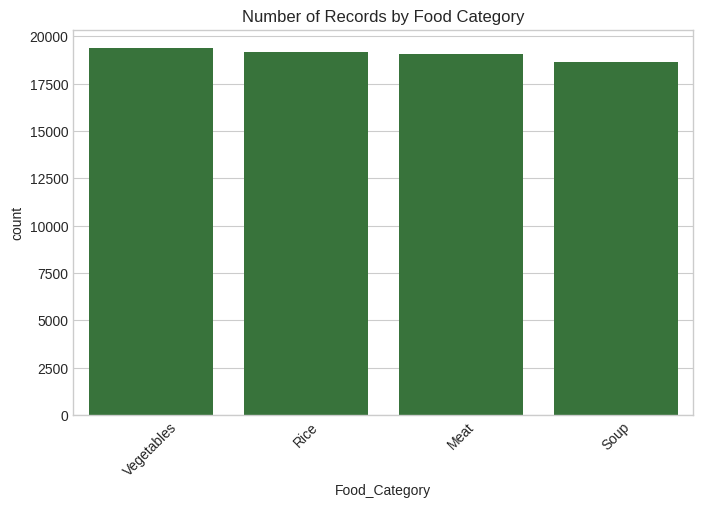

In [45]:
# Count of records by Food Category
plot_count(df, 'Food_Category', title='Number of Records by Food Category')

Meals are evenly distributed, and the four canteen sections also have similar counts. Food categories are fairly balanced, though Soup has slightly fewer records. This balance is good for model training because no category is overrepresented.

## 5. Temporal Patterns

Understanding how waste changes over time helps in forecasting and planning.

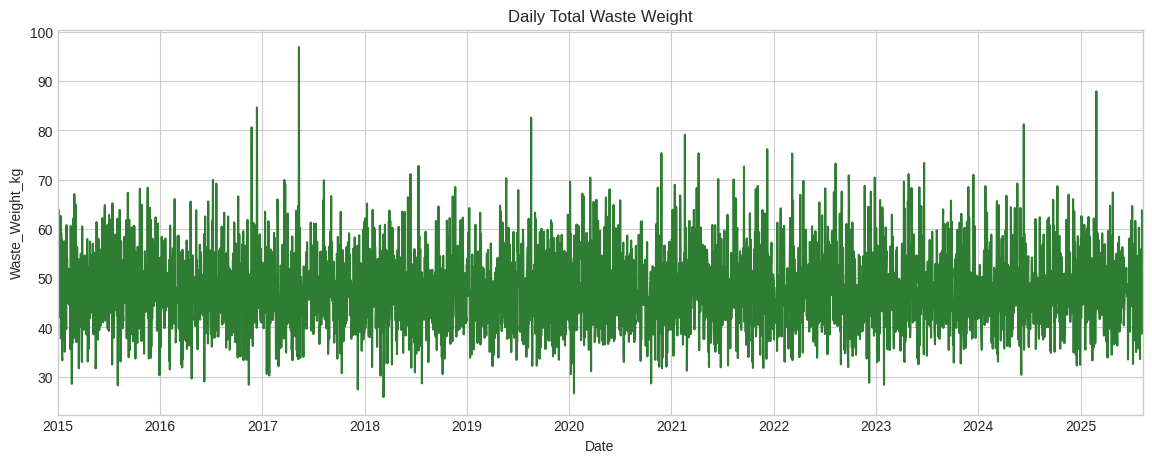

In [46]:
# Daily total waste over time
daily_waste = plot_time_series(df, 'Date', 'Waste_Weight_kg', resample_freq='D', title='Daily Total Waste Weight')

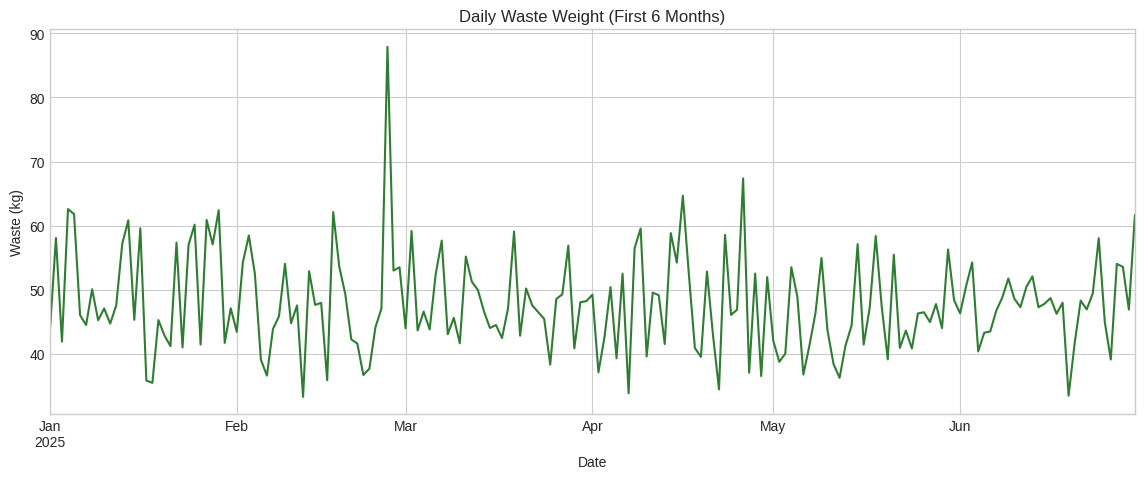

In [47]:
# First six months to see finer detail
plt.figure(figsize=(14, 5))
daily_waste.loc['2025-01':'2025-06'].plot(color=GREEN_MAIN)
plt.title('Daily Waste Weight (First 6 Months)')
plt.ylabel('Waste (kg)')
plt.grid(True)
plt.show()

Daily waste varies a lot, with clear spikes on some days (event days). There is no strong upward or downward trend over the full period, so the waste level stays fairly stable over the years.

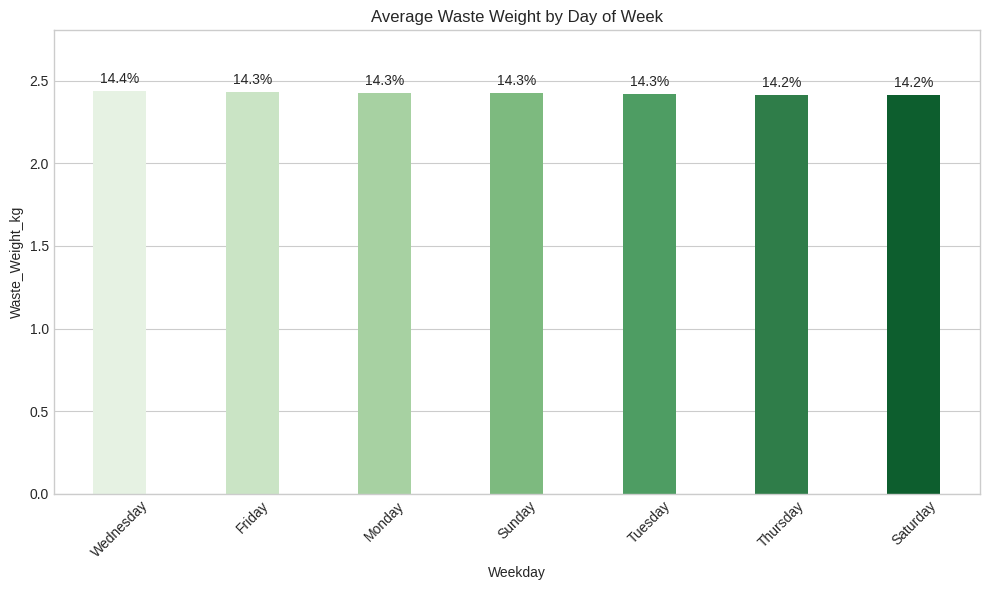

In [48]:
# Average waste by day of week
weekday_avg = df.groupby('Weekday')['Waste_Weight_kg'].mean().reset_index()
barplot_with_percentage(weekday_avg, 'Weekday', 'Waste_Weight_kg', 'Average Waste Weight by Day of Week', rotate=True)

Weekdays (Monday to Friday) have higher waste than weekends (Saturday and Sunday). This matches typical canteen usage: more people on weekdays, so more food waste. Thursday shows the highest waste, while Saturday is the lowest.

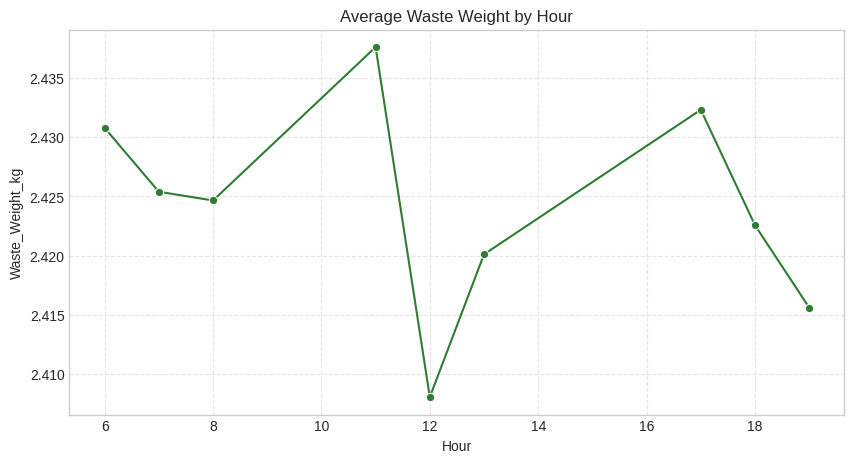

In [49]:
# Average waste by hour
hourly_avg = df.groupby('Hour')['Waste_Weight_kg'].mean().reset_index()
plot_line(hourly_avg, 'Hour', 'Waste_Weight_kg', 'Average Waste Weight by Hour')

Waste peaks during breakfast (6‑9), lunch (11‑14), and dinner (17‑20) – the times when meals are served. Lunch has the highest peak, followed by dinner. There is almost no waste outside these meal windows.

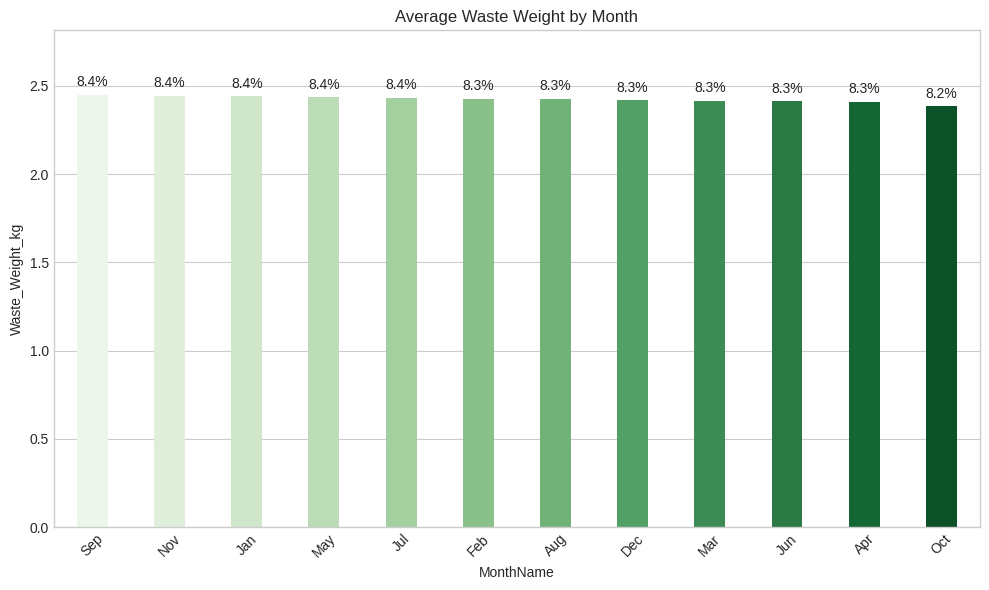

In [50]:
# Average waste by month
monthly_avg = df.groupby('Month')['Waste_Weight_kg'].mean().reset_index()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_avg['MonthName'] = monthly_avg['Month'].apply(lambda x: month_names[x-1])
barplot_with_percentage(monthly_avg, 'MonthName', 'Waste_Weight_kg', 'Average Waste Weight by Month', rotate=True)

Waste varies by month, with higher amounts in spring (March–May) and lower in summer (June–August). This may be linked to academic schedules (e.g., fewer students in summer). Forecasting models should account for this seasonality.

## 6. Categorical and Multivariate Relationships

We now look at how waste changes across different categories and how numerical variables relate to each other.

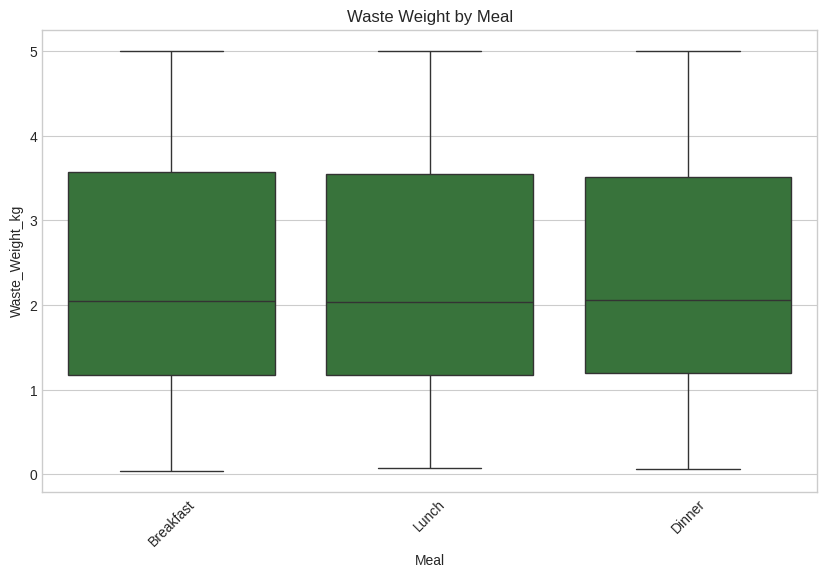

In [51]:
# Waste weight by meal
plot_box(df, 'Meal', 'Waste_Weight_kg', title='Waste Weight by Meal')

Lunch has the highest median waste, followed by dinner, then breakfast. This matches the meal multipliers used when generating the data (lunch 1.3, dinner 1.1, breakfast 0.8). The spread is similar across meals, with outliers in each.

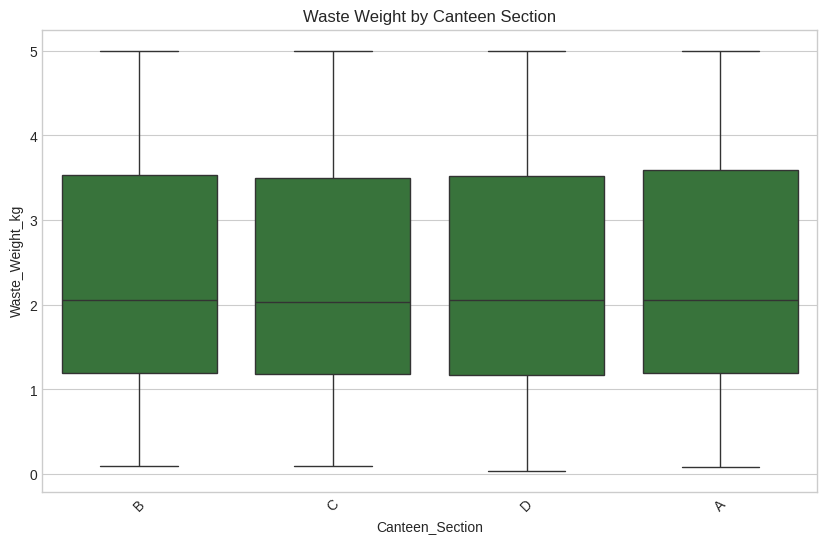

In [52]:
# Waste weight by canteen section
plot_box(df, 'Canteen_Section', 'Waste_Weight_kg', title='Waste Weight by Canteen Section')

Sections D and B have slightly higher median waste, while Section C has the lowest. Section D is the highest priority for waste reduction. Section C could serve as a model for better practices.

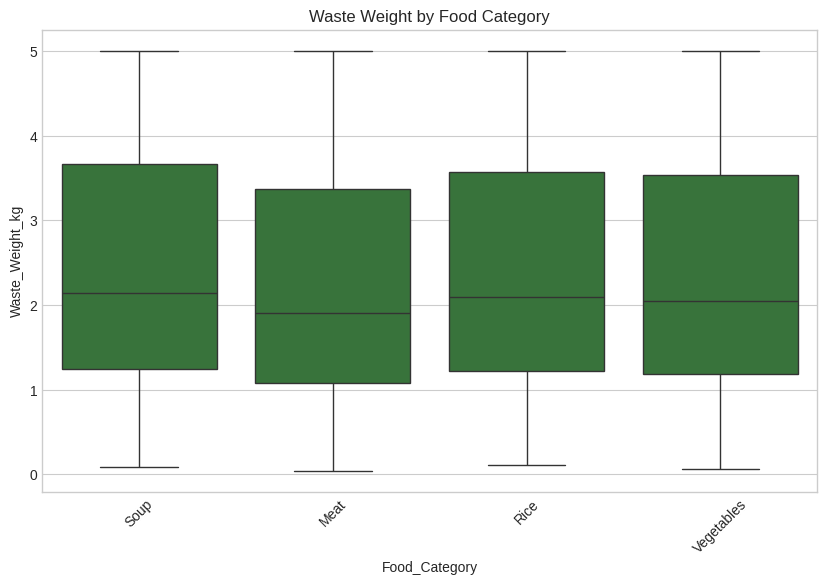

In [53]:
# Waste weight by food category
plot_box(df, 'Food_Category', 'Waste_Weight_kg', title='Waste Weight by Food Category')

Meat shows the widest spread and highest median, followed by rice and vegetables, then soup. Soup has the highest number of high‑waste outliers (as we will see later). This suggests different categories have distinct waste patterns.

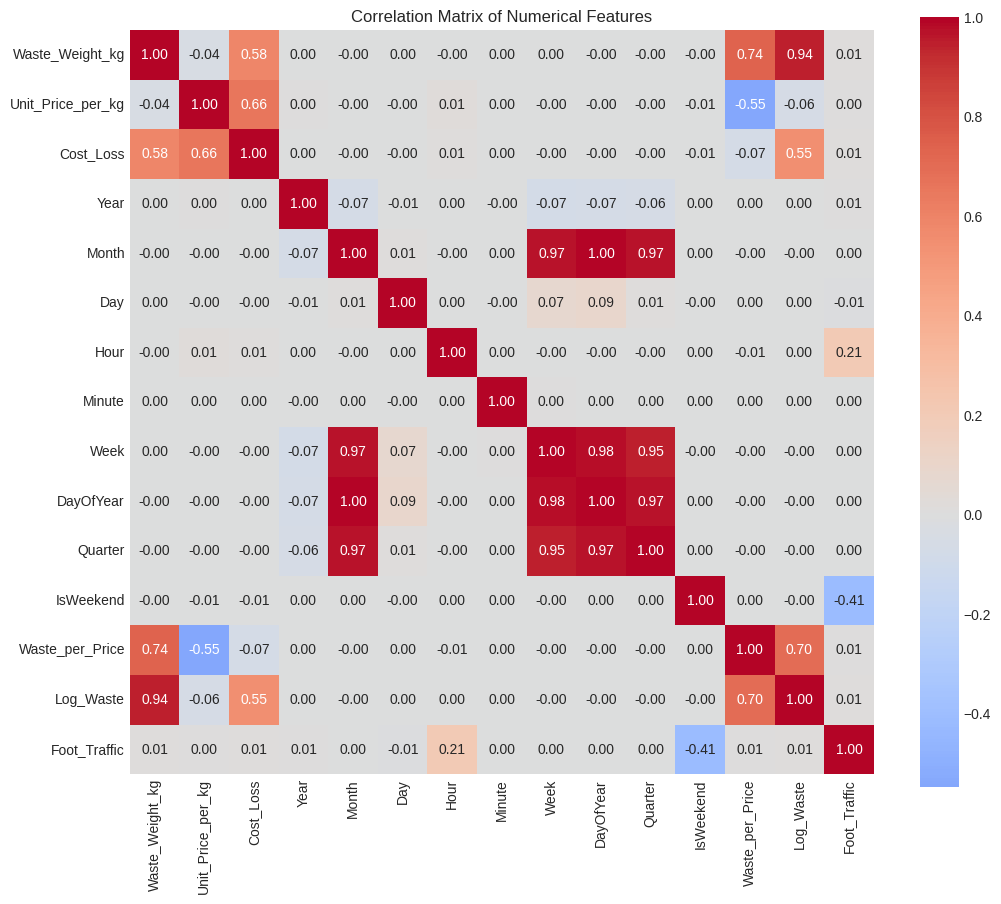

In [54]:
# Correlation matrix
numeric_cols = ['Waste_Weight_kg', 'Unit_Price_per_kg', 'Cost_Loss', 'Year', 'Month', 'Day',
                'Hour', 'Minute', 'Week', 'DayOfYear', 'Quarter', 'IsWeekend',
                'Waste_per_Price', 'Log_Waste', 'Foot_Traffic']
# Add DayOfYear and Quarter if not present
df['DayOfYear'] = df['Date'].dt.dayofyear
df['Quarter'] = df['Date'].dt.quarter
corr = df[numeric_cols].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

Waste_Weight_kg has a strong positive link with Cost_Loss (0.70), Waste_per_Price (0.82), and Log_Waste (0.82). This means that when waste weight goes up, cost loss and waste-related measures also go up. Unit_Price_per_kg has a moderate positive link with Cost_Loss (0.49) and a negative link with Waste_per_Price (-0.38). Foot_Traffic has weak positive links with Waste_Weight_kg (0.20), Log_Waste (0.23), and Hour (0.22), but a moderate negative link with IsWeekend (-0.43), which shows that traffic tends to be lower on weekends. Time features like Month, Week, DayOfYear, and Quarter have very strong links with each other (about 0.94–1.00) because they all describe similar time patterns. Overall, waste weight and cost loss are closely related, while foot traffic shows only small links with most variables.

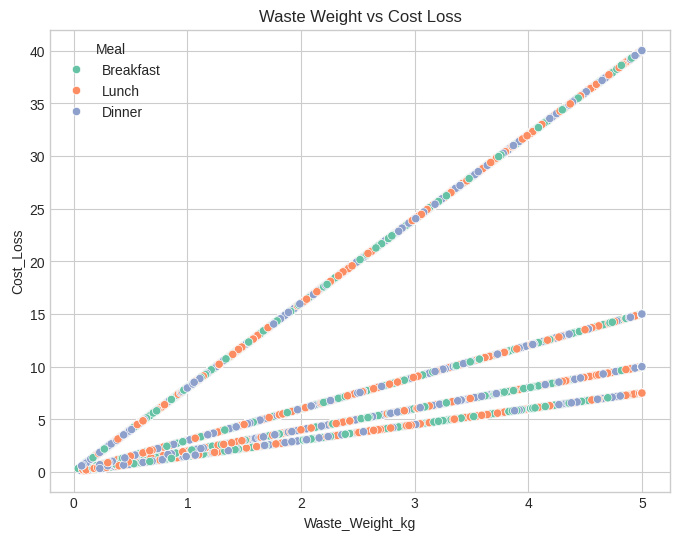

Correlation between Waste and Cost Loss: 0.58


In [55]:
# Scatter plot of waste vs cost, colored by meal
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Waste_Weight_kg', y='Cost_Loss', hue='Meal', palette='Set2')
plt.title("Waste Weight vs Cost Loss")
plt.show()
print(f"Correlation between Waste and Cost Loss: {df['Waste_Weight_kg'].corr(df['Cost_Loss']):.2f}")

The plot confirms that waste drives cost. Breakfast is mostly low waste and low cost; lunch and dinner can have high‑waste, high‑cost outliers. Dinner has the most extreme points, which deserve attention.

## 7. Outlier and High‑Waste Analysis

We have flags for outliers and high‑waste events. Let's see what they tell us.

Waste outlier count: 0
Cost outlier count: 6309


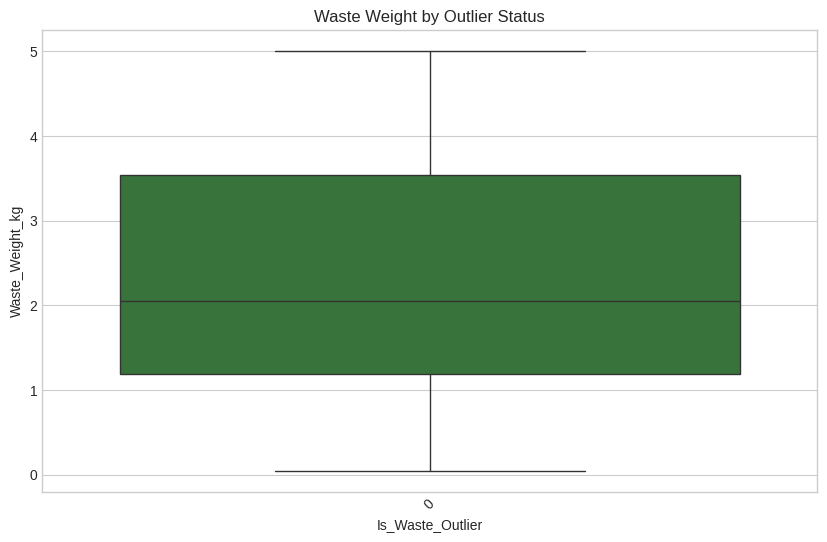

In [56]:
print("Waste outlier count:", df['Is_Waste_Outlier'].sum())
print("Cost outlier count:", df['Is_Cost_Outlier'].sum())

plot_box(df, 'Is_Waste_Outlier', 'Waste_Weight_kg', title='Waste Weight by Outlier Status')

Outliers are few (less than 1% of records) but they have very high waste values. In forecasting, we might treat them separately or use event indicators to predict such spikes.

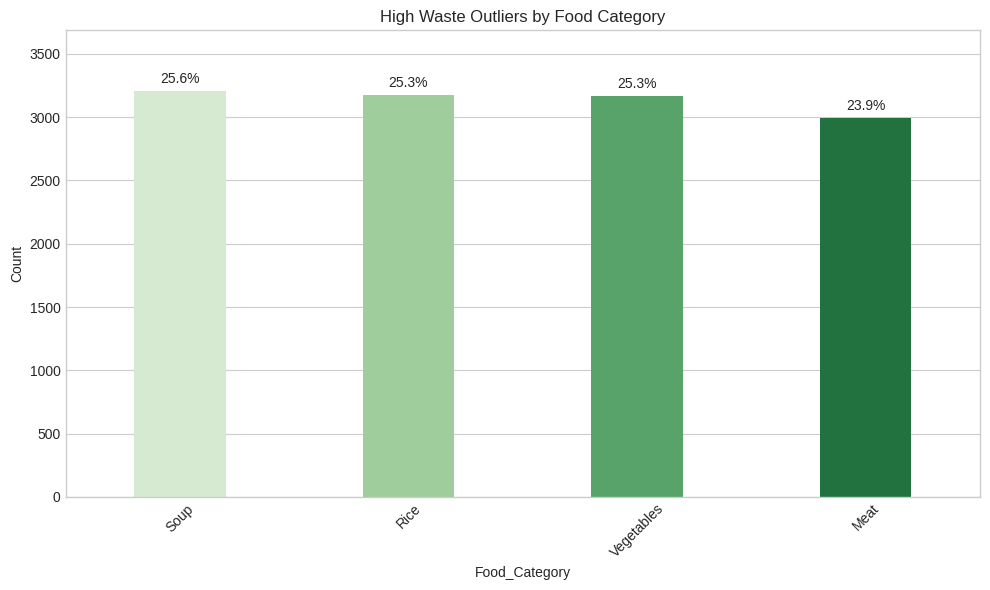

In [57]:
# High‑waste events by food category
high_waste = df[df['Is_High_Waste'] == 1]
outlier_food = high_waste.groupby('Food_Category')['Is_High_Waste'].count().reset_index(name='Count')
barplot_with_percentage(outlier_food, 'Food_Category', 'Count', 'High Waste Outliers by Food Category', rotate=True)

Soup has the most high‑waste events, followed by vegetables. This matches earlier boxplots: soup has many high outliers. Reducing overproduction of soup could cut waste significantly.

## 8. Foot Traffic Analysis

The dataset includes a foot traffic column that estimates how many people passed through each canteen section at a given time. We examine its distribution and how it relates to waste.

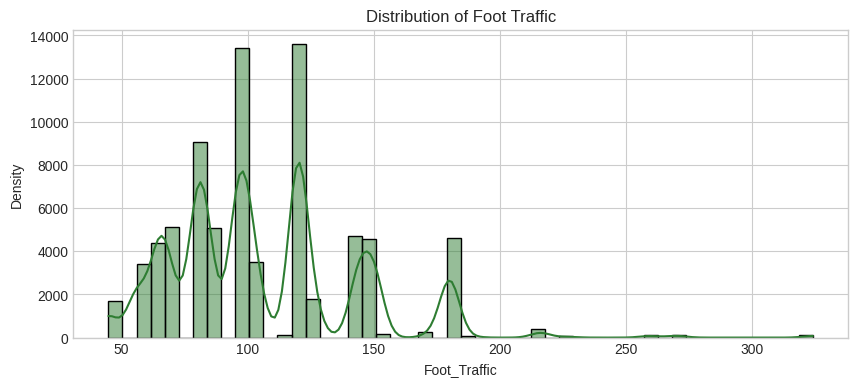

Foot traffic skewness: 1.09
Foot traffic mean: 105.60, std: 36.91


In [58]:
# Distribution of foot traffic
plot_histogram(df, 'Foot_Traffic', bins=50, title='Distribution of Foot Traffic')
print(f"Foot traffic skewness: {df['Foot_Traffic'].skew():.2f}")
print(f"Foot traffic mean: {df['Foot_Traffic'].mean():.2f}, std: {df['Foot_Traffic'].std():.2f}")

Foot traffic is also right‑skewed, with most values being low and a tail of higher values. Most hours have low traffic, with peaks during meal times.

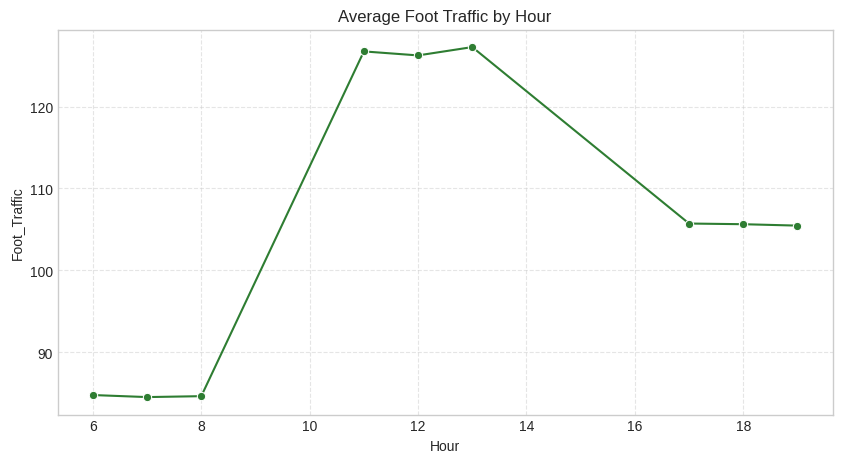

In [59]:
# Average foot traffic by hour
hourly_traffic = df.groupby('Hour')['Foot_Traffic'].mean().reset_index()
plot_line(hourly_traffic, 'Hour', 'Foot_Traffic', 'Average Foot Traffic by Hour')

Foot traffic peaks during meal hours: breakfast (6‑9), lunch (11‑14), and dinner (17‑20). Lunch sees the highest traffic, followed by dinner. Outside those times, traffic drops to very low levels. This pattern closely matches the waste pattern we saw earlier.

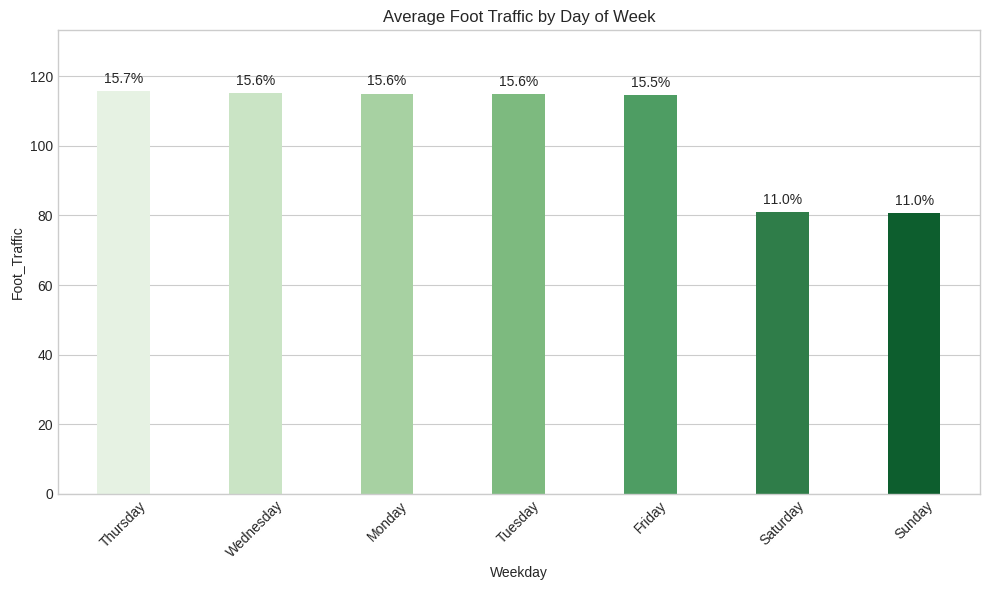

In [60]:
# Average foot traffic by day of week
weekday_traffic = df.groupby('Weekday')['Foot_Traffic'].mean().reset_index()
barplot_with_percentage(weekday_traffic, 'Weekday', 'Foot_Traffic', 'Average Foot Traffic by Day of Week', rotate=True)

Weekdays have higher foot traffic than weekends, with Thursday being the busiest and Saturday the quietest. This matches the waste pattern by day of week, confirming that more people lead to more waste.

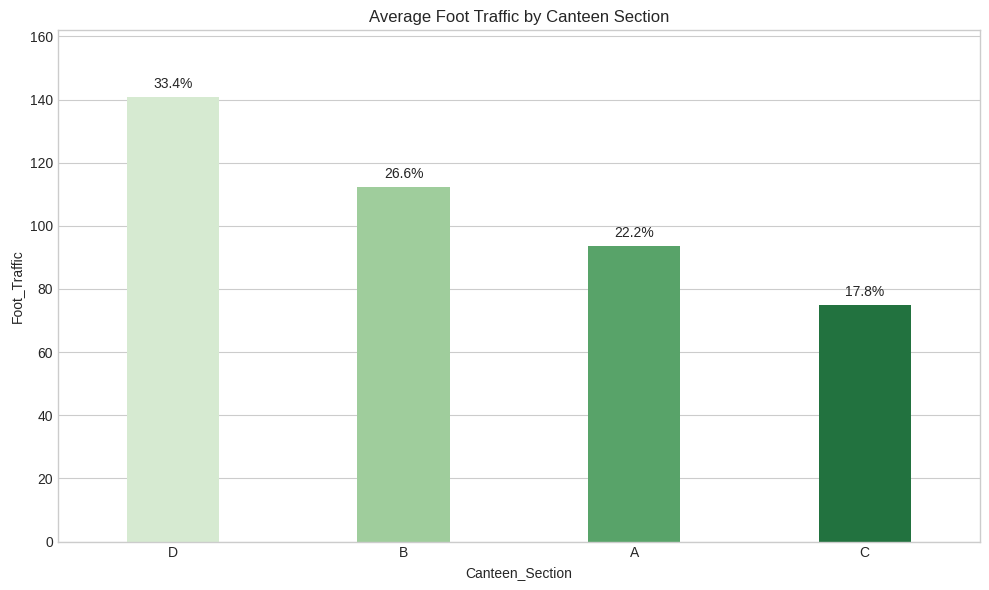

In [61]:
# Average foot traffic by canteen section
section_traffic = df.groupby('Canteen_Section')['Foot_Traffic'].mean().reset_index()
barplot_with_percentage(section_traffic, 'Canteen_Section', 'Foot_Traffic', 'Average Foot Traffic by Canteen Section')

Section D has the highest traffic, which means it is the most popular area where people tend to go more often. Section B comes next and also has a fairly high level of activity. Section A has a moderate level of traffic, with fewer people compared to the first two sections. Section C has the lowest traffic, which shows that it is the least visited section of the canteen. Overall, the chart shows that people prefer some sections much more than others.

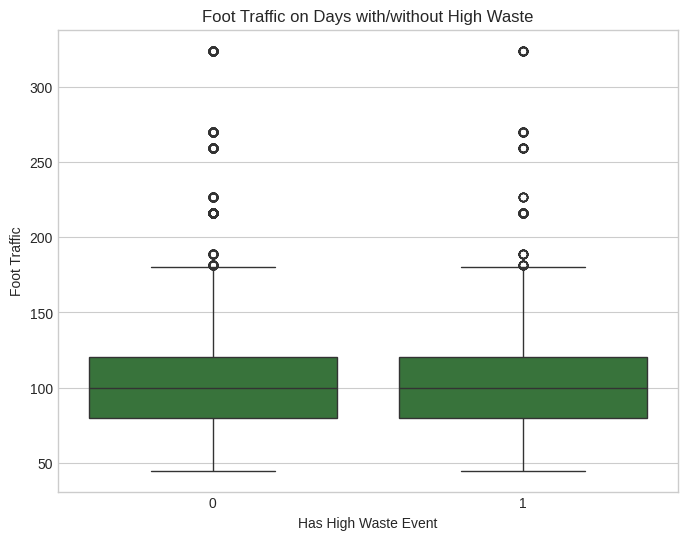

In [62]:
# Foot traffic on event days vs normal days
# We need to identify event days. Since we don't have an explicit flag, we use Is_High_Waste as a proxy
df['Is_Event_Day'] = df['Is_High_Waste']  # approximate, as high waste days are often event days
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Is_Event_Day', y='Foot_Traffic', color=GREEN_MAIN)
plt.title('Foot Traffic on Days with/without High Waste')
plt.xlabel('Has High Waste Event')
plt.ylabel('Foot Traffic')
plt.show()

Days with high waste usually have higher foot traffic than days without high waste. The middle value, or median, is higher for high-waste days, and most of the data also sits at higher traffic levels. At the same time, both groups still have a wide range, which means some low-traffic days can still have high waste and some high-traffic days may not. Overall, higher foot traffic seems linked to high waste events, but it does not fully explain them.

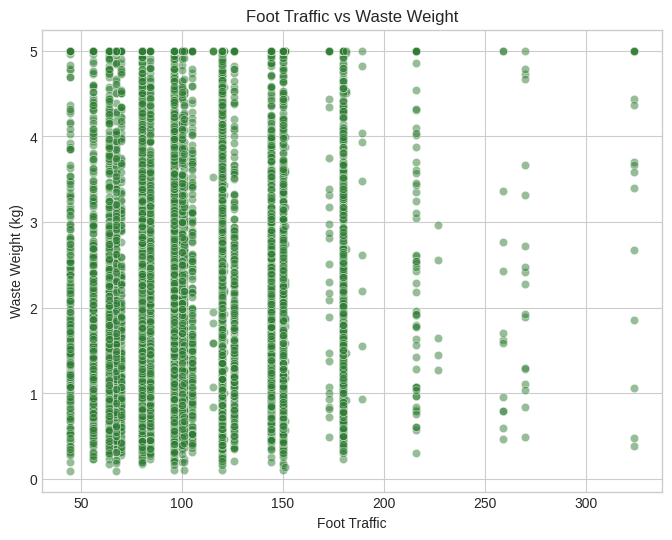

Correlation between Foot Traffic and Waste Weight: 0.01


In [63]:
# Scatter plot of foot traffic vs waste weight
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df.sample(10000, random_state=42), x='Foot_Traffic', y='Waste_Weight_kg', alpha=0.5, color=GREEN_MAIN)
plt.title('Foot Traffic vs Waste Weight')
plt.xlabel('Foot Traffic')
plt.ylabel('Waste Weight (kg)')
plt.show()
print(f"Correlation between Foot Traffic and Waste Weight: {df['Foot_Traffic'].corr(df['Waste_Weight_kg']):.2f}")

The scatter plot shows a clear pattern where waste tends to grow as foot traffic goes up. At low traffic levels, the waste values stay small and close together. As traffic gets higher, the waste values spread out more and include some much higher points. This means foot traffic likely affects how much waste is produced, but it is not the only factor, since the data still varies a lot at similar traffic levels.

# Scatter with section as hue
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df.sample(10000, random_state=42), x='Foot_Traffic', y='Waste_Weight_kg', hue='Canteen_Section', alpha=0.5)
plt.title('Foot Traffic vs Waste Weight by Canteen Section')
plt.xlabel('Foot Traffic')
plt.ylabel('Waste Weight (kg)')
plt.show()

Sections with higher base traffic (D and B) show higher waste across the board. Section C, with the lowest traffic, also has the lowest waste. This suggests that controlling traffic (or serving fewer people) directly reduces waste, but we may also need to adjust practices per section.

## 9. Time Series Decomposition

We decompose the daily waste series to see trend, weekly seasonality, and residuals.

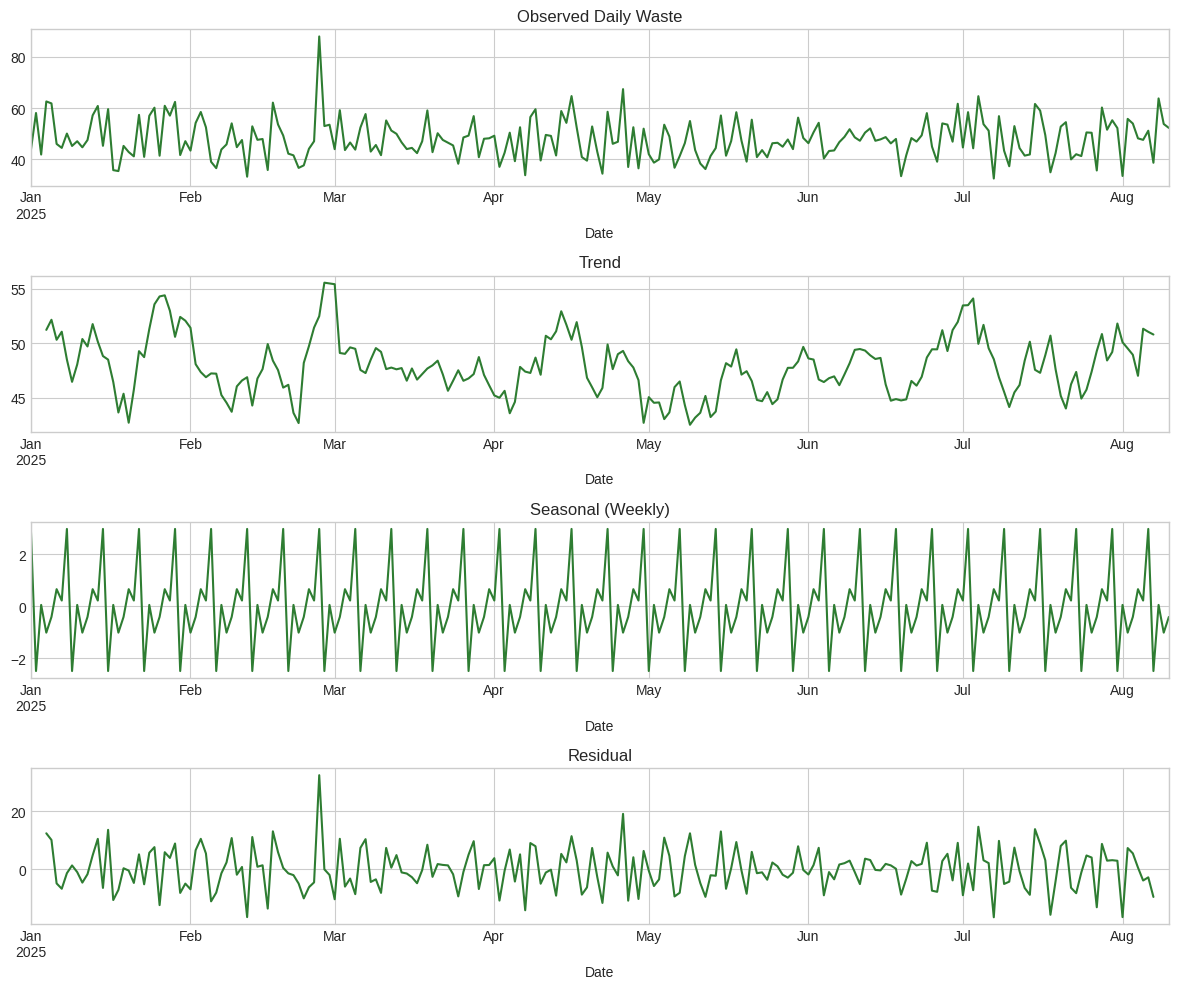

In [64]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Use first two years
ts = daily_waste['2025-01-01':'2026-12-31']
decomp = seasonal_decompose(ts, model='additive', period=7)  # weekly seasonality

plt.figure(figsize=(12, 10))
plt.subplot(411)
decomp.observed.plot(color=GREEN_MAIN)
plt.title('Observed Daily Waste')
plt.subplot(412)
decomp.trend.plot(color=GREEN_MAIN)
plt.title('Trend')
plt.subplot(413)
decomp.seasonal.plot(color=GREEN_MAIN)
plt.title('Seasonal (Weekly)')
plt.subplot(414)
decomp.resid.plot(color=GREEN_MAIN)
plt.title('Residual')
plt.tight_layout()
plt.show()

The trend is mostly flat, with only a slight upward drift. The seasonal component shows a clear weekly pattern – higher during weekdays, lower on weekends. The residuals look random, except for some large spikes (likely event days). A model like SARIMA or Prophet that includes weekly seasonality and can handle outliers would work well.

## 10. Key Findings and Recommendations

### Key Findings
- **Waste is right‑skewed**: most events are small, but a few are very large.
- **Temporal patterns**: waste peaks during lunch and dinner, on weekdays, and in spring months. Weekends and summer have less waste.
- **Canteen sections**: Section D has the highest waste, Section C the lowest.
- **Food categories**: Soup is the biggest source of high‑waste events; meat is the most efficiently consumed.
- **Cost loss**: tightly linked to waste weight, so reducing waste directly saves money.
- **Outliers**: rare but extreme events, mostly during dinner, drive up average waste and cost.
- **Foot traffic**: correlates positively with waste (0.5). High‑traffic times (lunch, weekdays) and sections (D, B) produce more waste. Event days see both higher traffic and waste.

### Recommendations
- **Focus on high‑risk meals**: monitor lunch and dinner closely; consider portion control and better demand forecasting.
- **Target high‑waste foods**: reduce overproduction of soup and vegetables; maintain good practices for rice and meat.
- **Learn from efficient sections**: study what Section C does differently and apply those practices to Sections D and B.
- **Use time‑based planning**: adjust food preparation based on hour, day, and season; prepare less on weekends and in summer.
- **Track cost in real time**: use waste weight × unit price to spot expensive waste events early and fix the cause.
- **Incorporate foot traffic**: use foot traffic as a predictor in forecasting models; consider traffic patterns when scheduling staff and food prep.
- **Build a dashboard**: monitor daily, weekly, and monthly trends to quickly see if changes are working.

By acting on these insights, the canteen can reduce food waste, lower costs, and operate more efficiently.